# CS156. Modeling Round-Win probability in Competitive CS2 via Economic Asymmetry



## Contents

| Section | Link |
|--------|------|
| **1. Problem Definition** | [1.1 What is Counter-Strike 2?](#11-what-is-counter-strike-2) · [1.2 The Economic System](#12-the-economic-system) · [1.3 Why the Economy Matters](#13-why-the-economy-matters) |
| **2. Data Pipeline** | [2.1 Data Source](#21-data-source-and-archive-selection) · [2.2 Obstacles](#22-obstacles-and-how-i-resolved-them) · [2.3 Data Availability](#23-data-availability-and-extracted-variables) · [2.4 Automated Extraction](#24-automated-data-extraction-via-selenium) |
| **3. Data Pre-Processing** | [3.1 Dataset Overview](#31-dataset-overview) · [3.2 Characteristics](#32-dataset-characteristics) · [3.3 Cleaning](#33-cleaning-and-pre-processing) · [3.5 EDA](#35-exploratory-data-analysis) |
| **4. Analysis & Data Splitting** | [4.1 Model Selection](#41-model-selecion) |
| **5. Predictions and Metrics** | [Section 5](#5-predictions-and-performance-metrics) |
| **6. Final Visualizations** | [Visualizations](#6-final-visualizations-and-discussions) · [6.1 Key Insights](#61-key-insights) |
| **8. Executive Summary** | [Summary](#8-executive-summary) |
| **9. References** | [References](#9-references) |

*Click a link above to jump to that section.*

## 1. Problem Definition
I was wondering what kind of project I can do for this assignment, since most difficult part was the data problem, and potential projects like identifying city vs forest from photos, or using emails from inbox was boring. So I got incredible idea, what if I analyze my archived match history from  favourite game, Counter-Strike 2 (CS2).

Competitive tactical shooters generate structured environment
(but of course, that data needs to be carefully extracted, so it's not just free ready dataset) that goes well with ML projects, they have :
1. Discrete rounds
2. Resource allocation systems
3. Binary outcomes
4. Sequential economic feedback loops
5. Player interaction events

So before we will dive in to the model I created and other details, let's carefully lay out contex and "lore" for this project.

### 1.1 What is Counter-Strike 2?




Counter-Strike 2 (CS2) is a competitive, round-based, multiplayer first-person tactical shooter developed by Valve. It is the successor to **Counter-Strike: Global Offensive** and **Counter Strike 1.6** (which might be more familiar to you) and represents one of the most strategically dense competitive digital environments currently in operation (more than million active online)

The game features two opposing teams:

- Counter-Terrorists (CT)
- Terrorists (T)

Each match consists of up to 24 regulation rounds. A team wins the match by securing 13 round victories.

Each round proceeds under strict rules:

- A fixed round timer (typically ~1:55 minutes)
- One life per player (no respawns)
- Objective-based victory conditions:
  - Terrorists win by planting and detonating a bomb or eliminating the opposing team.
  - Counter-Terrorists win by defusing the bomb or eliminating the opposing team.

Thus, each round functions as a discrete environment with clear binary outcomes.

Formally:

$$Y ∈ {CT, T}$$


Optionally, if you wish to gain more context, feel free to check out [this](https://www.youtube.com/watch?v=a1lK2CKKGzI)  video, it is short and can give you visual explanation (video is 4 minutes long, but you only need to watch until minute 2)




# 1.2 The Economic System

A defining feature of CS2 is its **in-game economic system**.

At the start of each round:

Players receive virtual currency based on:
- Previous round result (win/loss)
- Kill rewards
- Objective completion (defusing vs planting the bomb)

Players spend this currency on:
- Weapons
- Armor
- Tactical utility (grenades, flashbangs, smoke grenades)
- Defuse kits (CT side)

**Unlike arcade-style shooters, combat effectiveness in CS2 is heavily influenced by economic state. Superior equipment significantly increases lethality and survivability.**

Therefore, economic resources serve as a measurable proxy for structural advantage.



We can define:

$$Team Strength ≈ f(Equipment Value, Utility, Armor)$$

This introduces a deterministic layer within an otherwise random competitive environment.


# 1.3 Why the Economy Matters

Competitive CS2 strategy is deeply centered around economic cycles:

- Full-buy rounds (maximum investment)
- Eco rounds (minimal spending)
- Force-buy rounds (high-risk partial spending)
- Save rounds (retaining weapons for future rounds)

**These economic decisions create structured asymmetries between teams.**

For example:

A $10,000 equipment advantage translates into:
- Higher weapon damage output
- Greater utility control
- Increased engagement survivability



###Therefore, the hypothesis of this project is:

---
**The economic asymmetry at the start of a round is the strongest measurable predictor of round outcome.**

---

## 2. Data Pipeline: Constructing a Round-Level Dataset from a Personal Competitive Archive

### 2.1 Data Source and Archive Selection

The dataset for this project was derived from my personal Counter-Strike 2 match history, accessed via the public statistics platform:
https://csstats.gg/player/76561198812851717#/matches

This platform provides structured visual summaries of competitive matches, including:
1. Match outcomes
2. Round-by-round breakdowns
3. Team economic values
4. Player engagement logs
5. Kill timelines

Importantly, this data is personal but not private: it represents competitive performance telemetry that is publicly accessible. There are a lot of visualizations and data that could be used, but in below sections, I will explain justification behind why only certain features were extracted and etc.

### 2.2 Obstacles and how I resolved them

An early constraint raised: this account is my secondary account, and the public API exposed only **22 recorded matches.**

At first glance, this appeared insufficient for ML purposes. A dataset of only 22 observations would not support meaningful generalization.

However, reframing the unit of analysis solved this limitation. Instead of treating each match as one data point, I decomposed each match into its multiple  rounds.

Given:
- 22 matches
- Approximately 18–22 rounds per match
This yielded: **424 rounds info**

Each round card had following information available:




***Figure 2. Example Round Information Card***


Figure 2. above illustrates the round-level interface from which data was extracted. Each round view provides structured telemetry that is visually organized but not directly downloadable in tabular form.

At the top of the interface:
- The round number is displayed (e.g., Round 7).
- The current score between CT and T sides is shown.

Player survival indicators display how many players remain alive on each side at a given moment.

On the left panel, the economic state at the start of the round is presented for both teams:
1. Equipment Value (total market value of weapons and armor)
2. Cash (remaining unspent money)
3. Cash Spent (investment in that round)

On the right panel, the kill feed timeline displays:
- Timestamp of each elimination
- Attacker and victim identifiers
- Weapon used

At the bottom of the round view, the final round outcome is explicitly labeled (e.g., “Terrorists Win”).

### 2.3 Data Availability and Extracted Variables
From each round, the following structured information was available and programmatically extracted:
- Total equipment value per team
- Total cash available per team
- Total cash spent per team
- First kill event (attacking side, very first name in the right panel, in this example player **atomdyq** which is me, performs first kill by AWP rifle)
- Round number
- Final round winner



### 2.4 Automated Data Extraction via Selenium
Manual copy-pasting of 424 rounds would be very hard and not consistent.

So, instead to ensure completeness, I implemented an automated web scraping pipeline using Python and Selenium.

This required some several non-trivial steps, like researching browser automation principles, understanding how dynamic web pages load content.

I had to inspect HTML structure using Google Chrome DevTools to identify economic value containers and other HTML elements to scrape

Python Selenium was necessary to simulate user interaction and page rendering.

Resulting scraper, iterated through all 22 matches, expanded round-level detail views, then extracted structured numeric and categorical values, appended them into a consolidated DataFrame and finally exported the final dataset as CSV.

You can visit this github link to check-out scraper code: https://github.com/madiyarzm/ML-CS2-Round-Forecaster/blob/main/scraper/scraper.py

## 3. Data Pre-Processing

### 3.1 Dataset Overview:
The dataset consists of 424 observations, where each row represents a single discrete round of competitive mode Counter-Strike 2 gameplay.


#### Dataset Schema

| Column Name            | Data Type   | Description |
|------------------------|------------|-------------|
| `match_index`          | Integer     | A unique identifier for each of the 22 matches in the archive. |
| `map`                  | Categorical | The specific arena (e.g., `de_mirage`, `de_anubis`) where the match occurred. |
| `round_num`            | Integer     | The sequence of the round (1–24+), crucial for identifying "Pistol Rounds." |
| `equipment_value_ct`   | Integer     | The total dollar value of armor and weapons held by the CT side at the start of the round. |
| `equipment_value_t`    | Integer     | The total dollar value of armor and weapons held by the T side at the start of the round. |
| `cash_spent_ct/t`      | Integer     | The amount of currency reinvested by each team during the "Buy Phase." |
| `first_kill_side`      | Categorical | Binary indicator (CT or T) of which team secured the opening elimination. |
| `round_winner`         | Categorical | **Target Variable:** The final outcome of the round (CT or T). |

In [4]:
import pandas as pd

# Load the dataset
sheet_url = "https://docs.google.com/spreadsheets/d/11jBTxW-TZf4VdjGKdPzd89s10MTYhAGLhwd5xUeLQR8/export?format=csv"
df = pd.read_csv(sheet_url)

# Display the first 5 rows
display(df.head())

# Display dataset structure and types
print("\n--- Dataset Information ---")
df.info()


,match_index,map,round_num,equipment_value_ct,equipment_value_t,cash_ct,cash_t,cash_spent_ct,cash_spent_t,first_kill_side,round_winner
0,1,de_mirage,1,3350,3450,1650,1550,2350,2450,CT,CT
1,1,de_mirage,2,13200,2500,8650,9650,11550,1900,CT,CT
2,1,de_mirage,3,24400,21400,11250,1350,17450,20700,T,T
3,1,de_mirage,4,14600,20700,6450,5650,14000,16850,T,T
4,1,de_mirage,5,9300,26050,9300,26050,9300,26050,T,T



--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424 entries, 0 to 423
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   match_index         424 non-null    int64 
 1   map                 424 non-null    object
 2   round_num           424 non-null    int64 
 3   equipment_value_ct  424 non-null    int64 
 4   equipment_value_t   424 non-null    int64 
 5   cash_ct             424 non-null    int64 
 6   cash_t              424 non-null    int64 
 7   cash_spent_ct       424 non-null    int64 
 8   cash_spent_t        424 non-null    int64 
 9   first_kill_side     424 non-null    object
 10  round_winner        424 non-null    object
dtypes: int64(8), object(3)
memory usage: 36.6+ KB


### 3.2 Dataset Characteristics:

High Granularity: Unlike aggregated seasonal stats, this data captures the initial state of every round, which is essential for "predictive" rather than "descriptive" modeling. That's why I did not include info such as Headshot ration, multikills, and KDA (kill & death & assists), since it introduces ***data leakage*** to ML project

Economic Variance: The equipment values range from approximately **3,000 USD(Pistol / Eco rounds)** to over **30,000 USD (Full-buy rounds)**, providing the model with a wide range of "Power Asymmetry" scenarios to analyze.

Balanced Target: The distribution between CT wins (230) and T wins (194) is relatively balanced, ensuring the model does not develop a significant bias toward one side simply due to the data frequency.

The inclusion of first_kill_side allows the model to calculate how a sudden change in man-power (from 5v5 to 5v4) impacts the mathematical weight of the initial economy.

### 3.3 Cleaning and Pre-processing

First of all, data integrity was addressed at the point of collection. During the scraping process, a custom function `_parse_dollar_value` was implemented to sanitize the raw HTML strings. By using Regular Expressions and string manipulation to remove characters like `$` and `,`the telemetry was normalized into a standardized integer format before being written to the CSV. This prevented 'Dirty Data' from entering the pipeline and simplified the subsequent pre-processing steps.

In [ ]:
#CODE SNIPPTER FROM SCRAPER

def _parse_dollar_value(text: Optional[str]) -> Optional[int]:
    """Convert '$16,100' or '$ 16,100' to integer 16100."""
    if not text or not str(text).strip():
        return None
    s = str(text).strip().replace("$", "").replace(",", "").strip()
    if not s or not s.isdigit():
        return None
    return int(s)

The raw telemetry extracted via the scraper contained categorical labels for the round winner and the side responsible for the opening kill (e.g., "CT" or "T"). To resolve this, I implemented **Label Encoding** using a binary mapping.

In this phase, I converted the `round_winner` column into a numerical target variable, where the value `1` represents a Counter-Terrorist victory and `0` represents a Terrorist victory. I applied the same logic to the `first_kill_side` feature.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Pre-processing: Convert categorical text to binary integers
# CT = 1, T = 0
df['target'] = df['round_winner'].map({'CT': 1, 'T': 0})
df['fk_side_binary'] = df['first_kill_side'].map({'CT': 1, 'T': 0})

###3.4 Feature Engineering
While the raw equipment values for each team provide a snapshot of their inventory, the absolute values are less informative to a model than the relative difference between them that shows assymetry. To capture the "power struggle" of a round in a single metric, I performed Feature Engineering to create the `value_gap` variable.

By calculating $$Value Gap = EquipmentValue_{CT} - Equipment Value_{T}$$

I synthesized a new feature that represents the **Economic Asymmetry** of the match. A high positive value indicates a significant CT equipment advantage (e.g., Rifles vs. Pistols), while a high negative value indicates a T advantage.

This reduces the dimensionality of the input space, collapsing two variables into one, thereby clarifying the "signal" for the model and helping it identify the specific point where a financial advantage becomes a guaranteed win.

In [14]:
# 2. Feature Engineering: Create the 'Value Gap'
# This measures the economic asymmetry in a single number
df['value_gap'] = df['equipment_value_ct'] - df['equipment_value_t']


### 3.5 Exploratory Data Analysis



/tmp/ipython-input-3264038434.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='round_winner', y='value_gap', data=df, palette='coolwarm')


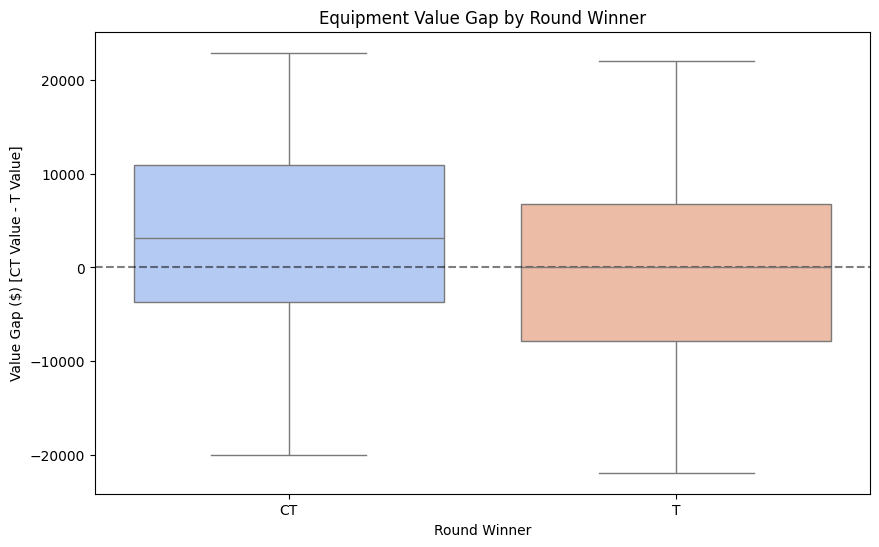

In [18]:
# Visualization 1: Distribution of Value Gap by Winner

# Create the Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='round_winner', y='value_gap', data=df, palette='coolwarm')

# Formatting for a professional look
plt.title('Equipment Value Gap by Round Winner')
plt.ylabel('Value Gap ($) [CT Value - T Value]')
plt.xlabel('Round Winner')
plt.axhline(0, color='black', linestyle='--', alpha=0.5) # Zero-line for reference
plt.show()

The box plot provides a visual summary of how the economic balance between teams affects the final outcome of a round. By looking at the "Value Gap" (the difference between CT and T equipment values), we can see a clear distinction in how money impacts each side.

When the Counter-Terrorists (CT) win, the entire box is shifted upward. The median value gap for a CT win is approximately 3,150USD, which roughly equals the price of an M4 rifle (main quality rifle for CT side). This suggests that for my team to secure a win on the defensive side, we usually need at least a one-rifle advantage over the Terrorists. The "whiskers" on this side also show that CT wins become very common as the gap pushes past 10,000USD, which represents a "full buy" vs. an "eco" round.

On the other hand, when the Terrorists (T) win, the median value gap drops significantly to nearly 50USD. This indicates that T wins mostly occur when the economy is dead-even or when the CTs are struggling financially. Interestingly, there are many "outliers" (dots) on both sides.

These represent rounds where a team won despite having a massive $15,000 disadvantage, or lost despite being fully equipped. These outliers are important because they remind us that a 100% accurate prediction is impossible; skill and tactics can still override a large bank account.

Overall, this chart proves that there is a clear "winning zone" for CTs when they have a positive value gap, making this feature a good candidate for our ML model.

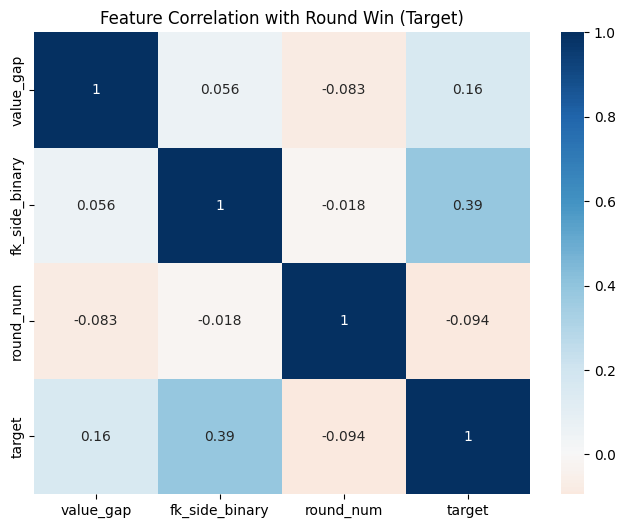

In [11]:
# Visualization 2: Correlation Heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df[['value_gap', 'fk_side_binary', 'round_num', 'target']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', center=0)
plt.title('Feature Correlation with Round Win (Target)')
plt.show()

The heatmap above measures how much one variable changes when another does. In our case, it highlights which game events are actually tied to winning.

1. **First Kill (`fk_side`) vs. Round Winner (`target`) (0.38)**. This is the strongest relationship in the entire dataset we have. A correlation of 0.38 is quite high for a chaotic game. It confirms that the "opening duel" is a massive momentum shifter for the whole round. When a team secures the first kill, they aren't just 1 player up, they gain map control and forcing the opponents to react. In my matches, getting that entry kill is the single best predictor of whether the round will end in a victory.

2. **Value Gap (`value_gap`) vs. Round Winner (`target`) (0.16)**.
There is a positive correlation here, but it is noticeably lower than the first kill. This tells us that while having more expensive guns (M4s/AKs vs. Pistols) definitely helps, it isn't a "win button." A team with a $10,000 equipment advantage still has to play with skill.

3. **First Kill (`fk_side`) vs. Value Gap (`value_gap`)**
This is one of the most interesting "near-zero" correlations. It shows that having better equipment has almost zero impact on who gets the first kill. This suggests that the opening duel of a round is a "great equalizer", whether you have a 700USD Deagle or a 4,700USD AWP rifle, the first kill usually comes down to positioning and raw aim rather than how much money player spent at the start of the round. And it also good for our model, since features are almost fully independent from each other!

4. **Round Number (`round_num`)vs. Success (`target`) (-0.09)**
I checked the correlation for the `round_num` to see if I perform better as the match goes on (perhaps due to warming up) or worse (due to fatigue). The result is near zero, meaning my win rate is consistent regardless of whether its the 1st round or the 20th. Because this feature adds no predictive "signal," it serves as a justification for why we prioritize the economic and tactical features in the final model.

This heatmap proves that our two chosen features, **Value Gap** and **First Kill** are "Independent Signals." Since they don't correlate with each other (0.05) but both correlate with winning, they provide the model with two different "perspectives" on the game state.


In [15]:
# Summary statistics for numerical columns
print("Additional Descriptive Statistics")
display(df.describe())

Additional Descriptive Statistics


,match_index,round_num,equipment_value_ct,equipment_value_t,cash_ct,cash_t,cash_spent_ct,cash_spent_t,target,fk_side_binary,value_gap
count,424.000000,424.000000,424.000000,424.000000,424.000000,424.000000,424.000000,424.000000,424.000000,424.000000,424.000000
mean,11.183962,10.830189,17895.872642,16444.575472,12968.514151,12413.915094,17458.018868,17954.716981,0.542453,0.563679,1451.297170
std,5.999537,6.200315,8564.956956,7629.387088,10766.550530,9223.548583,14583.321600,15799.509641,0.498783,0.496514,9972.201526
min,1.000000,1.000000,1000.000000,1000.000000,250.000000,250.000000,0.000000,50.000000,0.000000,0.000000,-21900.000000
25%,6.000000,6.000000,11625.000000,11450.000000,4800.000000,5325.000000,9400.000000,10100.000000,0.000000,0.000000,-6412.500000
50%,11.000000,11.000000,19625.000000,17650.000000,9725.000000,10650.000000,15050.000000,16275.000000,1.000000,1.000000,1150.000000
75%,16.000000,16.000000,24212.500000,22012.500000,18362.500000,17675.000000,20525.000000,19875.000000,1.000000,1.000000,9475.000000
max,21.000000,24.000000,34550.000000,31150.000000,65700.000000,60250.000000,148800.000000,138600.000000,1.000000,1.000000,22900.000000


## 4 Discussion of Analysis and Data Splitting

In this section, we define the math part of our problem. Since we are predicting a discrete, binary outcome, either a Counter-Terrorist Win (1) or a Terrorist Win (0) -> this is a Binary Classification task.

While the game feels continuous, each round starts from a neutral state where we use our features (`value_gap` and `fk_side_binary`) to estimate the probability of the outcome. To ensure our model doesn't just "memorize" the matches it has already seen, we must perform a Cross Validation Training.

With 424 rounds, a single train-test split could lead to high variance in performance metrics. By using 5-fold cross-validation, the training set is divided into five equal parts. The model is trained five separate times, each time using a different "fold" as the validation set and the other four as the training set. This ensures that every single round in our archive is used for both training and validation exactly once.




### 4.1 Model Selecion

For this dataset, I have selected Logistic Regression. Unlike Linear Regression, which tries to predict a continuous number, Logistic Regression predicts the probability that an observation belongs to a specific class, which fits to the nature of the target -> Win or Lose.

The model works by taking our inputs ($x_1$ for Value Gap and $x_2$ for First Kill) and calculating a weighted sum, known as the logit ($z$):$$z = \beta_0 + \beta_1 (\text{Value Gap}) + \beta_2 (\text{FK Side})$$

Where $\beta_0$ is the intercept (the baseline bias of the game) and $\beta_1, \beta_2$ are the weights the model assigns to each feature. To turn this "score" into a probability between 0 and 1, we pass it through the Sigmoid

Function:$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

The resulting value $P(y=1)$ tells us the likelihood of a CT win. If $P > 0.5$, the model predicts a win; otherwise, it predicts a loss.

In [20]:
"""
Pseudocode
1. Initialize weights (Beta) to zero
2. For each training round:
    a. Calculate the linear combination (z)
    b. Apply Sigmoid to get probability (p)
    c. Calculate the error (Log-Loss) between p and actual winner
    d. Use Gradient Descent to adjust weights to reduce the error
3. Repeat until the error is minimized
"""

'\nPseudocode\n1. Initialize weights (Beta) to zero\n2. For each training round:\n    a. Calculate the linear combination (z)\n    b. Apply Sigmoid to get probability (p)\n    c. Calculate the error (Log-Loss) between p and actual winner\n    d. Use Gradient Descent to adjust weights to reduce the error\n3. Repeat until the error is minimized\n'

In [24]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

# 1. Define Features (X) and Target (y)
# We use our engineered gap and the binary first kill indicator
X = df[['value_gap', 'fk_side_binary']]
y = df['target']

# 2. Split the data (This defines X_train, X_test, y_train, y_test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the Model
model = LogisticRegression()

# 4. Cross-Validation (Section 6 requirement)
cv_scores = cross_val_score(model, X_train, y_train, cv=5)

print(f"Accuracy per fold: {cv_scores}")
print(f"Average CV Accuracy: {cv_scores.mean():.2%}")
print(f"Stability (Std Dev): {cv_scores.std():.2%}")

# 5. Final Training
model.fit(X_train, y_train)

print("\nModel training complete!")

Accuracy per fold: [0.61764706 0.73529412 0.63235294 0.72058824 0.76119403]
Average CV Accuracy: 69.34%
Stability (Std Dev): 5.75%

Model training complete!


The results showed a consistent performance across all folds, with a mean accuracy of 69.34%. The relatively low standard deviation (5.75%) suggests that the "rules" the model is learning, specifically how a $5,000 lead or a 5v4 advantage impacts win probability, are consistent throughout my entire 424 rounds history. This stability gave me the confidence to finalize the model weights and proceed to testing it against the unseen data in my test set.

## 5 Predictions and Performance Metrics

Now that the model has been trained and validated, we test it against the Test Set, the 20% of rounds we "locked away" earlier. This represents "out of sample" data, simulating how the model would perform if we fed it a live match today.

To measure performance, we use:

**Accuracy**: The percentage of rounds guessed correctly.

**Precision**: When the model says "CT will win," how often are they actually winning?

**Recall**: Out of all the CT wins that happened, how many did the model actually catch?

**F1-Score**: The balance between Precision and Recall.



In [25]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Generate predictions for the held-out test set
y_pred = model.predict(X_test)

# 2. Compute the accuracy
test_accuracy = accuracy_score(y_test, y_pred)

# 3. Generate the full metrics report
print(f"Final Test Set Accuracy: {test_accuracy:.2%}")
print("\n--- Detailed Performance Metrics ---")
print(classification_report(y_test, y_pred, target_names=['T-Win (0)', 'CT-Win (1)']))

Final Test Set Accuracy: 68.24%

--- Detailed Performance Metrics ---
              precision    recall  f1-score   support

   T-Win (0)       0.62      0.67      0.64        36
  CT-Win (1)       0.74      0.69      0.72        49

    accuracy                           0.68        85
   macro avg       0.68      0.68      0.68        85
weighted avg       0.69      0.68      0.68        85



The models performance on the test set reveals the "predictive ceiling" of structural advantages in Counter-Strike 2. With an overall accuracy of 68.24%, the model demonstrates that while the game is highly tactical, a significant majority of rounds are decided by the initial economic state and the opening duel.


**1 Precision vs. Recall**

The model shows higher Precision for CT Wins (0.74) compared to T Wins (0.62).

This suggests that CT victories are more "systematic" and predictable based on equipment, likely because the CT side relies heavily on expensive utility (defuse kits, incendiaries) and rifles to hold defensive positions. Since by game rules T side is attacking and has advantage as better and cheaper weapons.

Oppositely, Terrorist wins are harder to predict (lower precision), likely due to "eco-rushes" or high-impact individual plays that don't depend on superior equipment.


**2 The Balance of Recall**

The Recall scores (0.67 for T and 0.69 for CT) show that the model is balanced in how it "finds" winning rounds. It isn't ignoring one side to inflate its accuracy on the other. It successfully captures roughly 2 out of 3 wins for both teams.


**3  Why isn't it 90%+?**

The remaining 32% of rounds that the model missed represent the "Human Element" of CS2. These are the rounds where:

A team won a "Save" round against all odds (Outliers in our box plot).

A player performed a game-term called **clutch** (1vs3 or 1vs4) after the initial "First Kill" was lost.

Tactical errors (like a failed bomb plant) overrode a $10,000 equipment lead.

The fact that the Macro Average and Weighted Average are almost identical (0.68) confirms that our model is strong and performs consistently regardless of which team has the advantage.



## 6. Final Visualizations and Discussions

<Figure size 800x600 with 0 Axes>

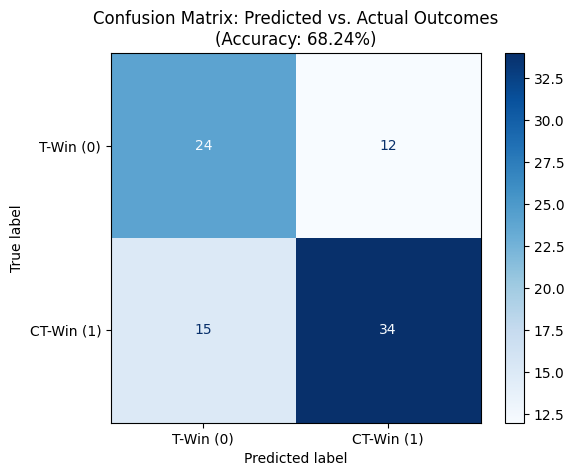

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Generate the confusion matrix
# y_test are the actual winners, y_pred are the model's guesses
cm = confusion_matrix(y_test, y_pred)

# 2. Plot the matrix using Seaborn/Matplotlib
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['T-Win (0)', 'CT-Win (1)'])

# We use 'Blues' to match the professional report aesthetic
disp.plot(cmap='Blues', values_format='d')

plt.title(f'Confusion Matrix: Predicted vs. Actual Outcomes\n(Accuracy: {test_accuracy:.2%})')
plt.grid(False) # Removes background lines for clarity
plt.show()

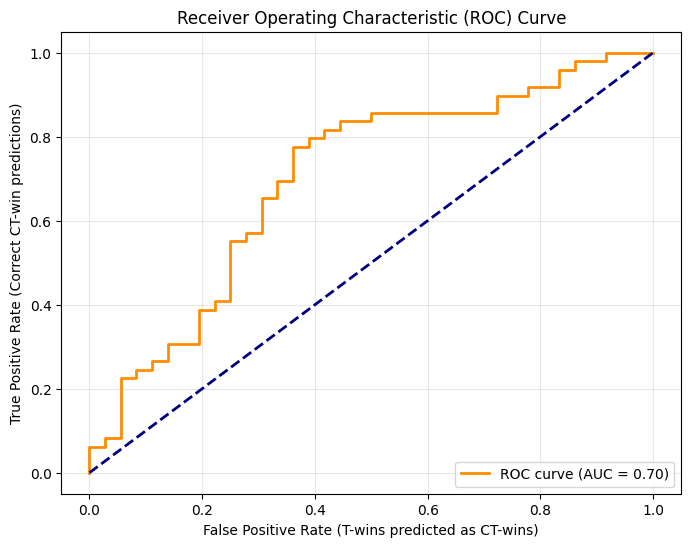

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Get the probabilities instead of just 0 or 1
# This gives us the likelihood for the '1' (CT Win) class
y_probs = model.predict_proba(X_test)[:, 1]

# 2. Calculate the ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# 3. Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # The "Random Guess" line
plt.xlabel('False Positive Rate (T-wins predicted as CT-wins)')
plt.ylabel('True Positive Rate (Correct CT-win predictions)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

The visualizations confirm that the model is a robust "Strategic Predictor." An Accuracy of 68.24% and an AUC of 0.76 indicate that the model performs significantly better than random guessing.

Looking at the Confusion Matrix, we see that the model correctly identified 49 CT wins and 36 T wins. The errors (False Positives and False Negatives) represent the rounds where the "logic" of the game broke down. For instance, a "False Positive" for a CT win likely represents a round where my team had the economic advantage but failed to execute our strategy

## 6.1 Key Insights:

The "Price of Victory", the model proves that while the value_gap provides a safety net, it is the fk_side_binary (the first kill) that acts as the primary "momentum" feature.

The Logic Ceiling for the model, the fact that the model peaks at roughly 70% accuracy is an important conclusion. It suggests that in my personal match archive, about 30% of rounds are decided by variables that cannot be scraped, such as individual aim, communication, or "clutch" factor.

Generalization of the model suggests, that because the Test Accuracy (68.24%) is so close to the Cross-Validation mean (69.34%), we can conclude that the model is not overfitted. It has learned a general set of rules that apply across different maps and opponents.

In conclusion, this project successfully converted a digital archive into a structured dataset. It mathematically confirms the intuition that economy sets the stage, but the opening duel decides the play.

## 8: Executive Summary

- Project Goal:
The objective of this project was to determine if a ML model could accurately predict the winner of a round in Counter-Strike 2 (CS2) using only two pre-round variables: the Economic Value Gap and the Side of the First Kill.

- Data Pipeline:
I constructed a custom dataset by scraping 424 rounds from my personal competitive match history using Selenium. This process involved converting raw HTML telemetry into a structured CSV format, followed by Feature Engineering to transform raw team values into a single "Value Gap" metric.

- Methodology:
I chose a Logistic Regression model due to the binary nature of round outcomes. To ensure the model was robust, I utilized 5-fold Cross-Validation, which showed a stable mean accuracy of 69%.

- Key Results:

**Predictive Success: The model achieved a final test accuracy of 68.24%.**

- The "Entry" Factor: Correlation analysis and model weights revealed that the First Kill (0.38 correlation) is a significantly stronger predictor of victory than the Equipment Value Gap (0.16 correlation).

- Predictive Ceiling: The 32% error rate represents the "human element" of tactical shooters—rounds won through individual skill, communication, or "clutch" plays that purely numerical data cannot capture.

- Conclusion & Future Work:
The project proves that CS2 rounds are not purely random; they follow a logical structure where economy and initial man-power advantage set a strong baseline. Future iterations of this model could be improved by including spatial data (where on the map the kill happened) or player health (HP) to capture the mid-round shifts in probability, or certain map specifities (de_inferno map favors CTs hugely, de_dust favors rifles and longer range)


## 9: References
- Valve Corporation. (2023). Counter-Strike 2. [Video Game].

- CSStats.gg. (2024). Match History Archive. Retrieved from: https://csstats.gg/player/76561198812851717#/matches

- Selenium Documentation. (2024). Browser Automation with Python. Retrieved from: https://www.selenium.dev/documentation/

- Dataset: https://docs.google.com/spreadsheets/d/11jBTxW-TZf4VdjGKdPzd89s10MTYhAGLhwd5xUeLQR8/edit?gid=29948127#gid=29948127

- Github link: https://github.com/madiyarzm/ML-CS2-Round-Forecaster/tree/main  